# Twin experiments — NRMSE evolution (Figure 6)

Per-generation minimum NRMSE for the six single-station optimisations and
the joint MERGED optimisation (Manuscript Figure 6, Section 3.4.1).

Inputs: `data/ga_logbook_{STATION}_{MODE}.parquet`.
Output: `figures/Figure_6.{pdf,png}`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml


def _project_root(marker: str = "pyproject.toml") -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Project root marker {marker!r} not found.")


PROJECT_ROOT = _project_root()
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

with open(PROJECT_ROOT / "parameters.yaml") as f:
    GA = yaml.safe_load(f)["genetic_algorithm"]
mode = GA["mode"]
experiments = GA["experiments"]

# Display labels (Manuscript Table 2 short names)
DISPLAY = {"BARENTS": "BARENTS", "PAPA": "PAPA", "Bay_of_Biscay": "BISCAY",
           "BATS": "BATS", "Canaries": "CANARY", "HOT": "HOT", "MERGED": "MERGED"}

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

## Load logbooks and reduce to per-generation min NRMSE

In [2]:
logbooks = {sid: pd.read_parquet(DATA_DIR / f"ga_logbook_{sid}_{mode}.parquet") for sid in experiments}


def _min_per_gen(df: pd.DataFrame) -> pd.DataFrame:
    # df.Fitness has one column per observation name; for single-station GA
    # there is one column, for MERGED there are six.
    fitness = df["Fitness"]
    stacked = (
        fitness.stack().rename("NRMSE")
        .reset_index()
        .groupby(["Generation", "name"])["NRMSE"]
        .min()
        .reset_index()
    )
    stacked["name"] = stacked["name"].map(DISPLAY).fillna(stacked["name"])
    return stacked


mono = pd.concat({DISPLAY[sid]: _min_per_gen(logbooks[sid]) for sid in experiments if sid != "MERGED"})
mono = mono.reset_index(level=0).rename(columns={"level_0": "station_exp"})
merged = _min_per_gen(logbooks["MERGED"]).assign(station_exp="MERGED")
mono.head()

,station_exp,Generation,name,NRMSE
0,BARENTS,0,BARENTS,0.288421
1,BARENTS,1,BARENTS,0.287408
2,BARENTS,2,BARENTS,0.363855
3,BARENTS,3,BARENTS,0.169114
4,BARENTS,4,BARENTS,0.152763


## Figure 6 — NRMSE per generation, single-station vs MERGED

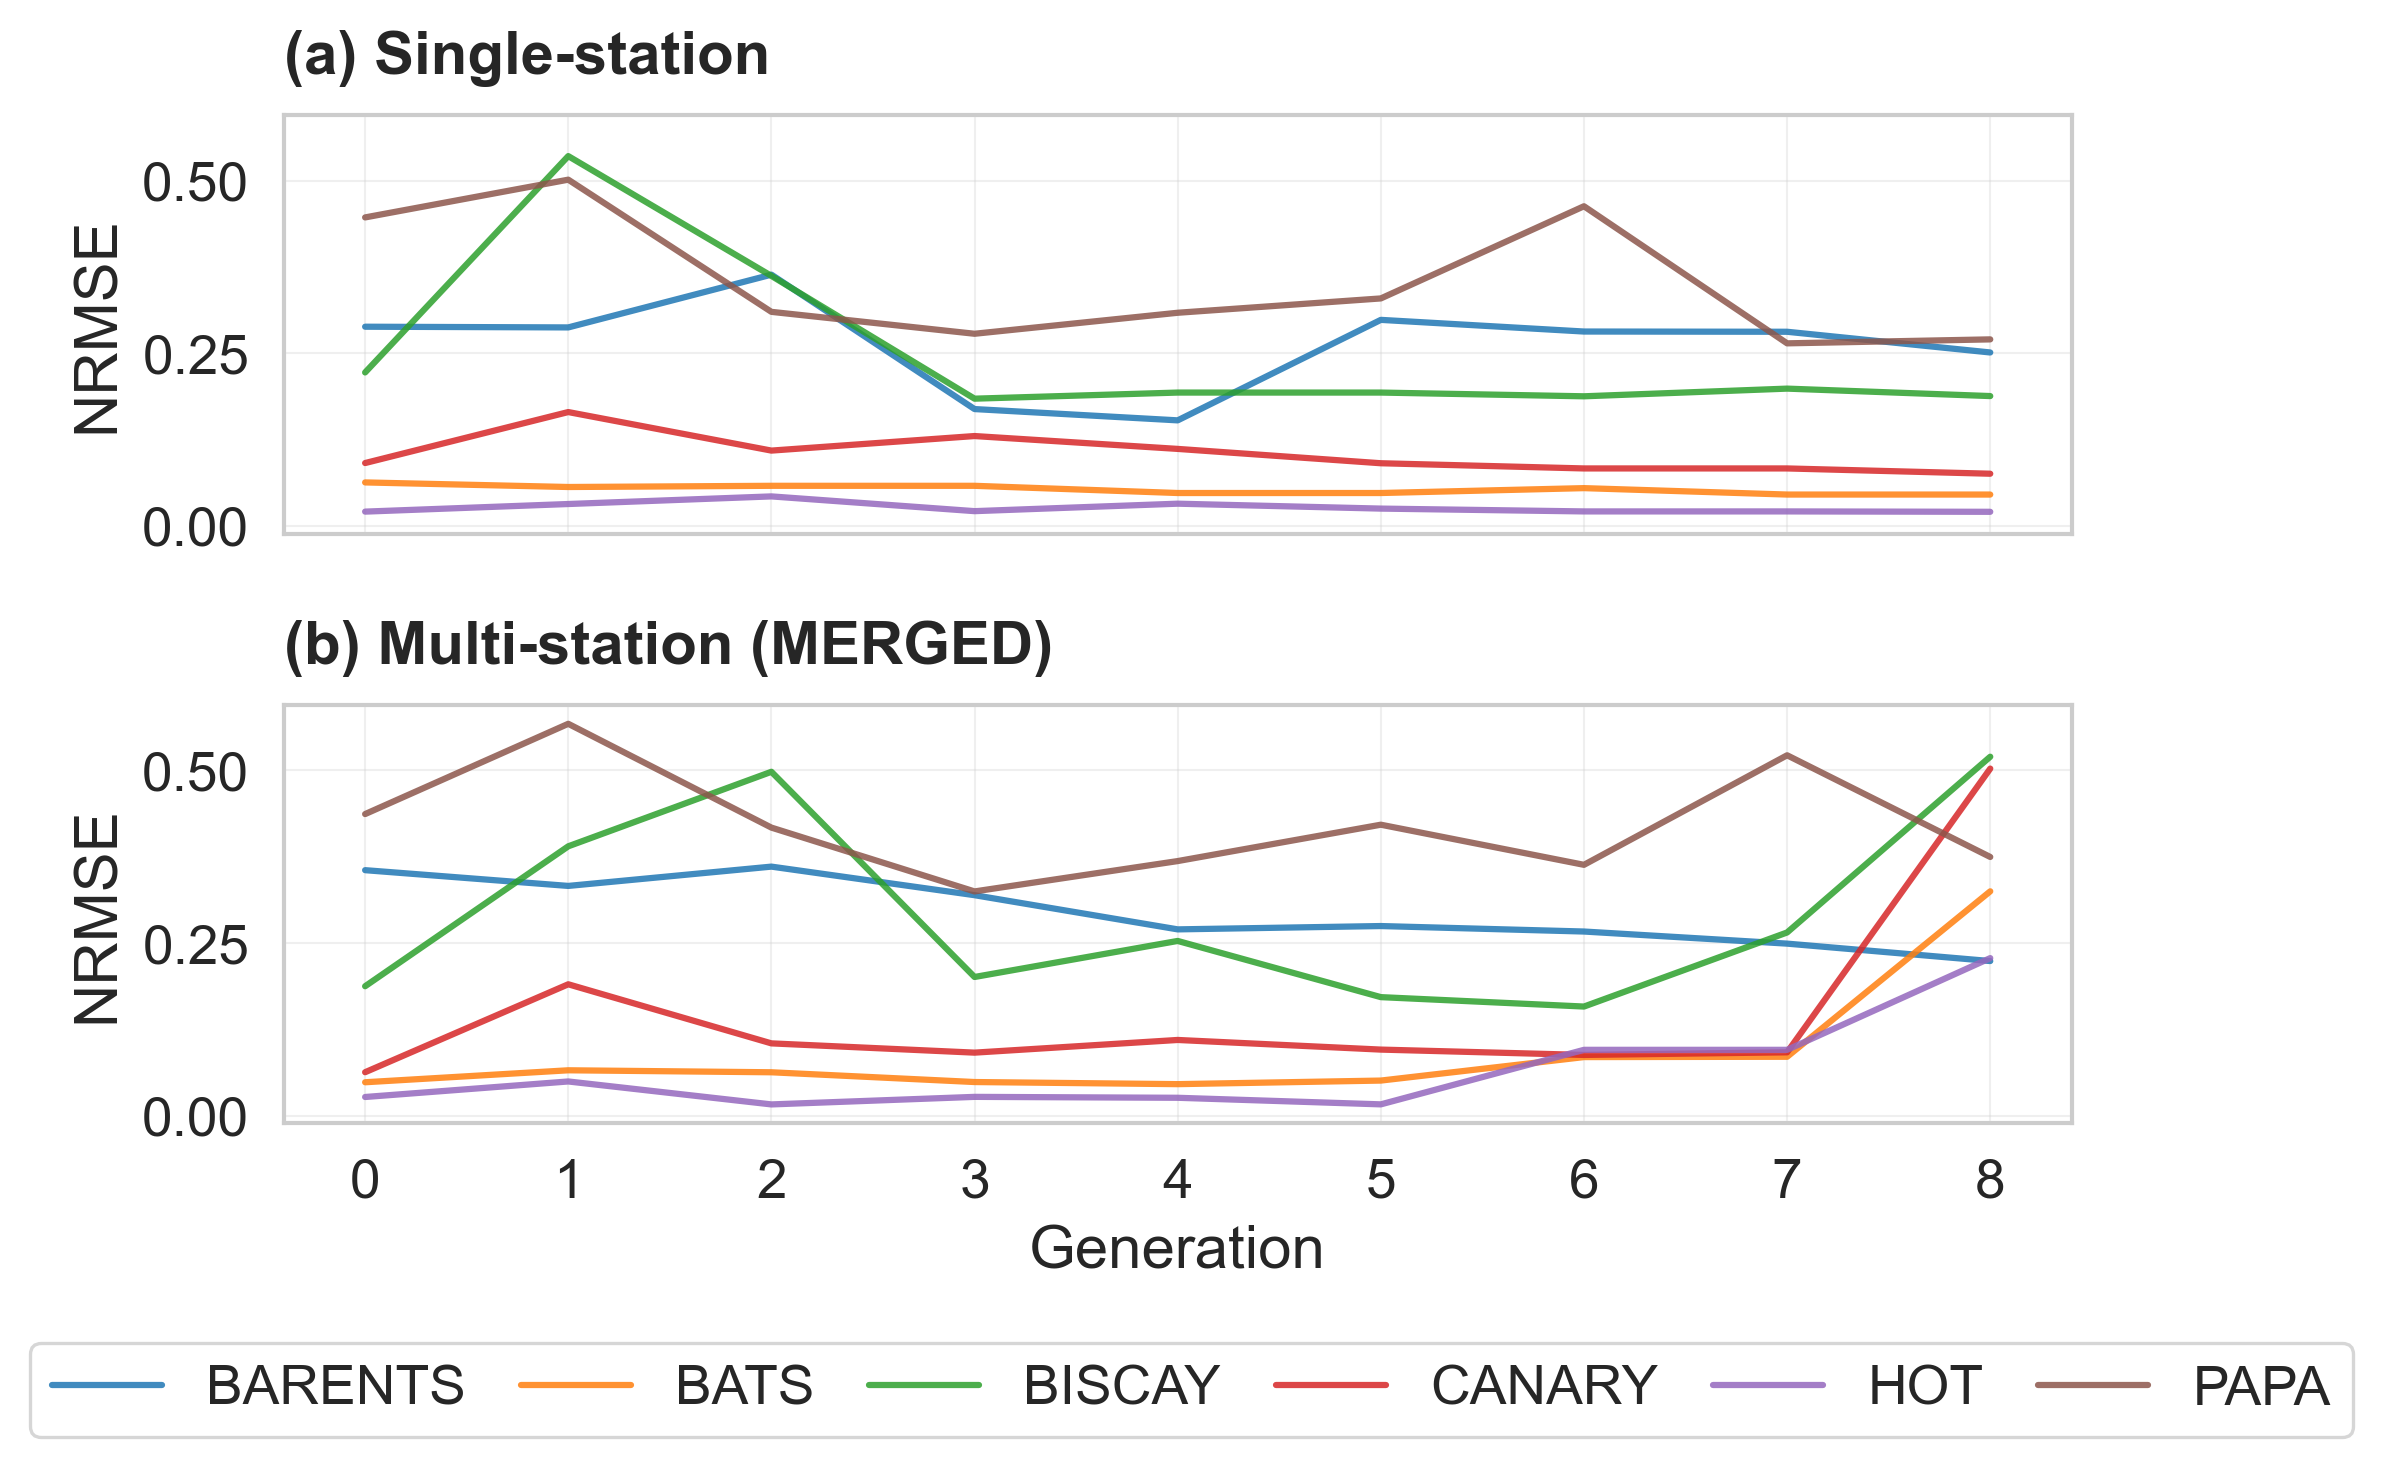

In [3]:
unique_names = sorted({n for n in pd.concat([mono, merged])["name"]})
color_map = dict(zip(unique_names, sns.color_palette("tab10", len(unique_names)), strict=True))

fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True, sharey=True, dpi=300)

for name in unique_names:
    sub = mono[(mono["station_exp"] == name) & (mono["name"] == name)]
    if not sub.empty:
        axes[0].plot(sub["Generation"], sub["NRMSE"], label=name,
                     color=color_map[name], linewidth=1.5, alpha=0.85)
    sub_m = merged[merged["name"] == name]
    if not sub_m.empty:
        axes[1].plot(sub_m["Generation"], sub_m["NRMSE"], label=name,
                     color=color_map[name], linewidth=1.5, alpha=0.85)

axes[0].set_title("(a) Single-station", fontweight="bold", loc="left", pad=10)
axes[1].set_title("(b) Multi-station (MERGED)", fontweight="bold", loc="left", pad=10)
for ax in axes:
    ax.set_ylabel("NRMSE")
    ax.grid(True, alpha=0.3, linewidth=0.5)
axes[1].set_xlabel("Generation")

fig.legend(
    *axes[0].get_legend_handles_labels(),
    loc="lower center", ncol=len(unique_names), frameon=True,
    bbox_to_anchor=(0.55, -0.0), columnspacing=1.0, handlelength=2.0,
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(FIGURES_DIR / "Figure_6.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "Figure_6.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()